# MediVision AI — Predictive Health Analytics

**What this notebook does:**
- Loads real US health survey data (NHANES)
- Cleans and prepares the data
- Explores patterns with charts and statistics
- Trains one machine learning model per disease
- Predicts risk for 6 chronic diseases at once

**Diseases predicted:** Diabetes · Hypertension · Heart Disease · Asthma · Stroke · Arthritis


## 1. Setup — Import Libraries

We load all the tools we need once at the top.


In [78]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")

# Chart style
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

# Folder where raw data files are stored
DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print("Data folder:", DATA_DIR.resolve())

Setup complete.
Data folder: D:\depi_graduation_project\MediVision-AI\data\raw


## 2. Download Data

We download health survey files from the **CDC (US Centers for Disease Control)**.
Each file covers a different topic (demographics, body measurements, blood tests, etc.).

Files are only downloaded if they don't already exist locally.


In [79]:
import requests
from tqdm.auto import tqdm

# Each file name maps to its CDC download URL
FILES = {
    "P_DEMO.xpt":   "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.xpt",
    "P_BMX.xpt":    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.xpt",
    "P_BPQ.xpt":    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPQ.xpt",
    "P_DIQ.xpt":    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DIQ.xpt",
    "P_GHB.xpt":    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GHB.xpt",
    "P_GLU.xpt":    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GLU.xpt",
    "P_HDL.xpt":    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_HDL.xpt",
    "P_MCQ.xpt":    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_MCQ.xpt",
    "P_PAQ.xpt":    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_PAQ.xpt",
    "P_SMQ.xpt":    "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_SMQ.xpt",
    "P_TCHOL.xpt":  "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_TCHOL.xpt",
    "P_TRIGLY.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_TRIGLY.xpt",
}

for filename, url in tqdm(FILES.items(), desc="Downloading"):
    path = DATA_DIR / filename
    if path.exists():
        print(f"  Already exists: {filename}")
        continue
    response = requests.get(url, stream=True)
    with open(path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"  Downloaded: {filename}")

print("\nAll files ready.")

Downloading: 100%|██████████| 12/12 [00:00<00:00, 4950.98it/s]

  Already exists: P_DEMO.xpt
  Already exists: P_BMX.xpt
  Already exists: P_BPQ.xpt
  Already exists: P_DIQ.xpt
  Already exists: P_GHB.xpt
  Already exists: P_GLU.xpt
  Already exists: P_HDL.xpt
  Already exists: P_MCQ.xpt
  Already exists: P_PAQ.xpt
  Already exists: P_SMQ.xpt
  Already exists: P_TCHOL.xpt
  Already exists: P_TRIGLY.xpt

All files ready.


## 3. Load & Clean Data

**Steps:**
1. Read each XPT file into a table
2. Merge all tables into one (joined on the respondent ID `SEQN`)
3. Rename confusing CDC codes to readable names
4. Keep only adults (age ≥ 18)
5. Create a yes/no column for each of the 6 diseases


In [80]:
# ── Step 1 & 2: Load and merge all files ─────────────────────────────────────
file_list = list(FILES.keys())
df = pd.read_sas(DATA_DIR / file_list[0], format="xport")

for filename in file_list[1:]:
    other = pd.read_sas(DATA_DIR / filename, format="xport")
    df = df.merge(other, on="SEQN", how="left")   # left join keeps all respondents

# Drop internal survey administration columns (not useful for prediction)
admin_cols = ["SIALANG","SIAPROXY","SIAINTRP","FIALANG","FIAPROXY","FIAINTRP",
              "MIALANG","MIAPROXY","MIAINTRP","AIALANGA","BMDSTATS",
              "SMAQUEX2","SDDSRVYR","RIDSTATR","RIDEXMON"]
df.drop(columns=[c for c in admin_cols if c in df.columns], inplace=True)

# ── Step 3: Rename columns to readable names ──────────────────────────────────
df = df.rename(columns={
    "RIAGENDR": "gender",            # 1=Male, 2=Female
    "RIDAGEYR": "age",               # Age in years
    "RIDRETH3": "ethnicity",         # Race/ethnicity category
    "DMDEDUC2": "education",         # Education level
    "DMDMARTZ": "marital_status",
    "INDFMPIR": "income_poverty_ratio",
    "BMXWT":    "weight_kg",
    "BMXHT":    "height_cm",
    "BMXBMI":   "bmi",
    "BMXWAIST": "waist_cm",
    "BMXHIP":   "hip_cm",
    "LBXGH":    "hba1c",             # Blood sugar average over 3 months
    "LBXGLU":   "fasting_glucose",   # Blood sugar after fasting
    "LBDHDD":   "hdl",               # Good cholesterol
    "LBXTC":    "total_cholesterol",
    "LBXTR":    "triglycerides",     # Blood fat
    "LBDLDL":   "ldl",               # Bad cholesterol
    "SMQ020":   "ever_smoked",
    "PAD680":   "sedentary_minutes", # Minutes sitting per day
})

# ── Step 4: Keep adults only ──────────────────────────────────────────────────
df = df[df["age"] >= 18].copy()

# ── Step 5: Create disease target columns (1=Yes, 0=No, NaN=Unknown) ──────────
if "DIQ010"  in df.columns:
    df["target_diabetes"]     = np.where(df["DIQ010"]==1, 1, np.where(df["DIQ010"].isin([2,3]), 0, np.nan))

if "BPQ020"  in df.columns:
    df["target_hypertension"] = np.where(df["BPQ020"]==1, 1, np.where(df["BPQ020"]==2, 0, np.nan))

if all(c in df.columns for c in ["MCQ160C","MCQ160D","MCQ160E"]):
    df["target_heart_disease"]= np.where(
        (df["MCQ160C"]==1)|(df["MCQ160D"]==1)|(df["MCQ160E"]==1), 1,
        np.where((df["MCQ160C"]==2)&(df["MCQ160D"]==2)&(df["MCQ160E"]==2), 0, np.nan))

if "MCQ010"  in df.columns:
    df["target_asthma"]       = np.where(df["MCQ010"]==1, 1, np.where(df["MCQ010"]==2, 0, np.nan))

if "MCQ160F" in df.columns:
    df["target_stroke"]       = np.where(df["MCQ160F"]==1, 1, np.where(df["MCQ160F"]==2, 0, np.nan))

if "MCQ160A" in df.columns:
    df["target_arthritis"]    = np.where(df["MCQ160A"]==1, 1, np.where(df["MCQ160A"]==2, 0, np.nan))

# Collect target column names and input feature names
disease_targets = [c for c in df.columns if c.startswith("target_")]

selected_features = [f for f in [
    "age","gender","ethnicity","bmi","waist_cm","weight_kg","height_cm",
    "hba1c","fasting_glucose","total_cholesterol","hdl","triglycerides","ldl",
    "ever_smoked","sedentary_minutes","education","income_poverty_ratio"
] if f in df.columns]

print(f"Dataset shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Disease targets: {disease_targets}")
print(f"Input features : {len(selected_features)} features")

Dataset shape  : 9,693 rows x 188 columns
Disease targets: ['target_diabetes', 'target_hypertension', 'target_heart_disease', 'target_asthma', 'target_stroke', 'target_arthritis']
Input features : 17 features


## 4. Exploratory Data Analysis (EDA)

Before building any model, we explore the data to understand:
- How many patients are in the dataset
- Which columns have missing values
- What the distributions look like
- Which diseases are rare vs. common
- How features relate to each other


### 4.1 EDA Setup

Define colour constants and group columns by type.

In [81]:
# Colours used across all charts
BLUE   = "#2196F3"   # primary bars
ORANGE = "#FF7043"   # highlight / positive class

# Friendly disease names for chart titles
DISEASE_NICE = {t: t.replace("target_","").replace("_"," ").title()
                for t in disease_targets}

# Split columns by type
NUM_COLS = [c for c in [
    "age","bmi","waist_cm","hba1c","fasting_glucose",
    "total_cholesterol","hdl","triglycerides","ldl",
    "sedentary_minutes","income_poverty_ratio"
] if c in df.columns]

CAT_COLS = [c for c in [
    "gender","ethnicity","education","marital_status","ever_smoked"
] if c in df.columns]

print("Numeric columns :", NUM_COLS)
print("Categorical cols:", CAT_COLS)

Numeric columns : ['age', 'bmi', 'waist_cm', 'hba1c', 'fasting_glucose', 'total_cholesterol', 'hdl', 'triglycerides', 'ldl', 'sedentary_minutes', 'income_poverty_ratio']
Categorical cols: ['gender', 'ethnicity', 'education', 'marital_status', 'ever_smoked']


### 4.2 Dataset Overview

A quick look at the size, memory, and a sample of rows.


In [82]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"Memory  : {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print()

# Show a few rows
preview = NUM_COLS[:5] + CAT_COLS[:2] + disease_targets[:3]
df[preview].head(5)

Rows    : 9,693
Columns : 188
Memory  : 14.0 MB



,age,bmi,waist_cm,hba1c,fasting_glucose,gender,ethnicity,target_diabetes,target_hypertension,target_heart_disease
3,29.0,37.8,117.9,5.2,NaN,2.0,6.0,0.0,0.0,0.0
4,21.0,NaN,NaN,NaN,NaN,2.0,2.0,0.0,0.0,0.0
5,18.0,NaN,NaN,NaN,NaN,2.0,3.0,0.0,0.0,NaN
8,49.0,29.7,120.4,5.6,103.0,1.0,3.0,0.0,0.0,0.0
10,36.0,21.9,86.8,5.1,NaN,1.0,3.0,0.0,0.0,0.0


### 4.3 Missing Values

Many columns have missing data — especially blood-test columns,
because those were only collected from a sub-sample of adults.

> **Note:** Our model can handle missing values automatically, so we don't need to fill them in.


In [83]:
# Count missing values and compute percentage
miss = (df.isnull().sum()
          .rename("count")
          .to_frame()
          .assign(percent=lambda x: x["count"]/len(df)*100)
          .query("count > 0")
          .sort_values("percent", ascending=False))

print(f"{len(miss)} columns have missing values out of {df.shape[1]} total.")

# Colour the table — darker red = more missing
display(miss.style
    .background_gradient(cmap="Reds", subset=["percent"])
    .format({"count": "{:,}", "percent": "{:.1f}%"}))

156 columns have missing values out of 188 total.


,count,percent
RIDAGEMN,"9,693",100.0%
BMIRECUM,"9,693",100.0%
BMXHEAD,"9,693",100.0%
BMIHEAD,"9,693",100.0%
BMXRECUM,"9,693",100.0%
RHD018,"9,693",100.0%
MCQ151,"9,693",100.0%
SMQ621,"9,693",100.0%
SMD630,"9,693",100.0%
MCQ149,"9,693",100.0%


### 4.4 Basic Statistics

For each numeric feature, we compute:
- **mean / median** — typical value
- **std** — how spread out the values are
- **skewness** — how lopsided the distribution is (0 = balanced)
- **kurtosis** — how heavy the tails are (0 = normal)


In [84]:
stats = df[NUM_COLS].agg(
    ["count","mean","median","std","min","max",
     lambda x: round(x.skew(), 2)])
stats.index = ["count","mean","median","std","min","max","skewness"]

# Highlight extreme skewness/kurtosis in red
display(stats.T.style
    .background_gradient(cmap="coolwarm", subset=["skewness"])
    .format("{:.2f}"))

,count,mean,median,std,min,max,skewness
age,9693.00,49.59,50.00,18.61,18.00,80.00,-0.03
bmi,8790.00,29.88,28.60,7.60,14.20,92.30,1.35
waist_cm,8449.00,100.40,99.00,17.35,56.40,187.50,0.52
hba1c,8464.00,5.83,5.60,1.11,2.80,16.20,3.31
fasting_glucose,4173.00,112.91,103.00,37.53,47.00,451.00,3.92
total_cholesterol,8298.00,184.41,181.00,40.98,71.00,446.00,0.65
hdl,8298.00,53.46,51.00,15.86,5.00,189.00,1.33
triglycerides,4100.00,108.25,88.00,93.44,10.00,2684.00,9.55
ldl,4068.00,107.78,104.00,35.54,7.00,357.00,0.74
sedentary_minutes,9676.00,399.29,300.00,806.46,0.00,9999.00,10.94


### 4.5 How Many People Have Each Disease?

Each bar chart shows how many patients tested **positive** vs **negative**.
The ratio tells us how unbalanced the dataset is.

> A ratio of 10:1 means for every 1 sick patient there are 10 healthy ones.
> This imbalance is handled automatically by our model using `class_weight='balanced'`.


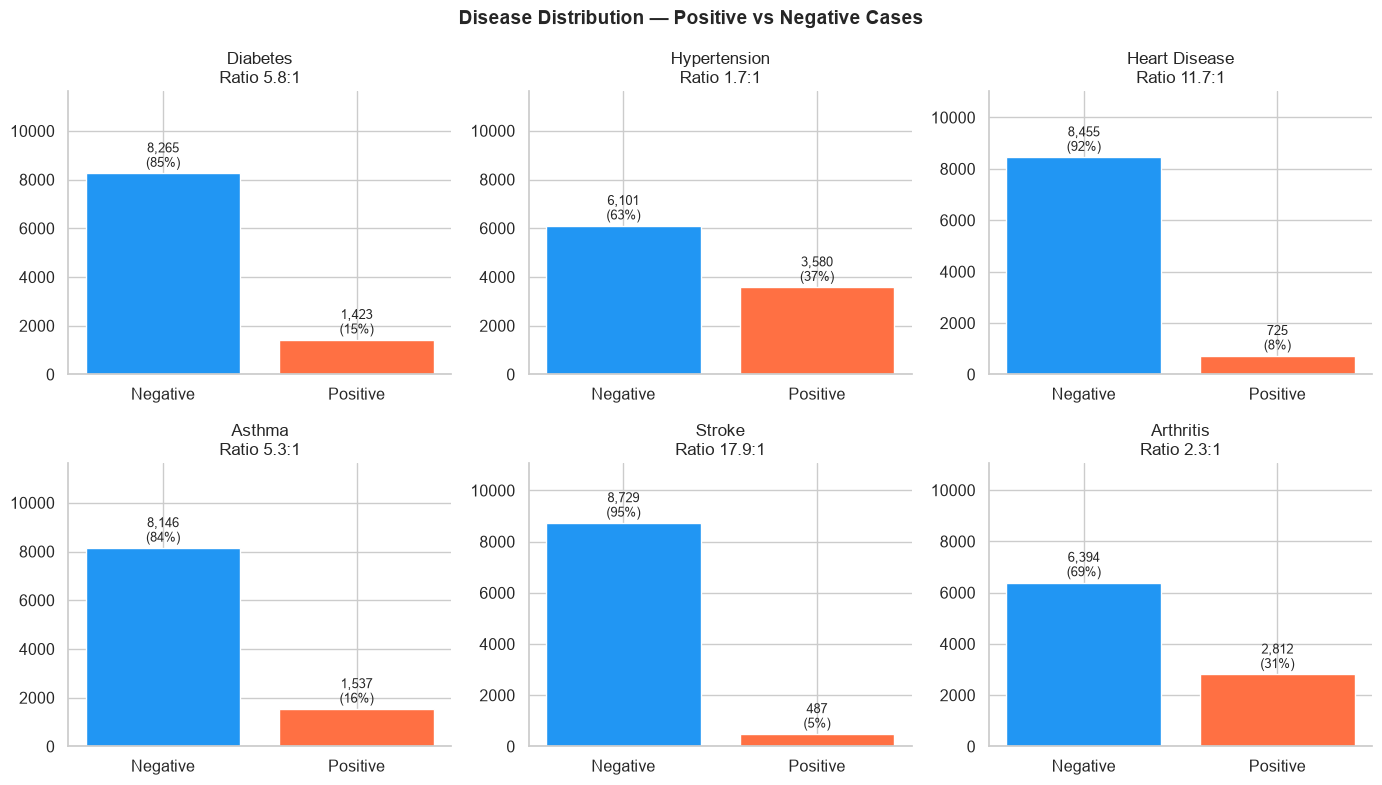

In [85]:
ncols = 3
nrows = -(-len(disease_targets) // ncols)   # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = np.array(axes).flatten()

for i, target in enumerate(disease_targets):
    vc  = df[target].value_counts(dropna=True).sort_index()
    neg = int(vc.get(0, 0))
    pos = int(vc.get(1, 0))
    total = neg + pos

    axes[i].bar(["Negative", "Positive"], [neg, pos],
                color=[BLUE, ORANGE], edgecolor="white")
    axes[i].set_title(
        f"{DISEASE_NICE[target]}\nRatio {neg/pos:.1f}:1" if pos else DISEASE_NICE[target])
    axes[i].set_ylim(0, total * 1.2)

    for j, v in enumerate([neg, pos]):
        axes[i].text(j, v + total*0.01,
                     f"{v:,}\n({v/total:.0%})", ha="center", va="bottom", fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Disease Distribution — Positive vs Negative Cases",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.6 Feature Distributions

Histograms for every numeric feature.

- **Red dashed line** = mean (average)
- **Orange dashed line** = median (middle value)
- If mean > median, the data is right-skewed (a few very high values pull the average up)


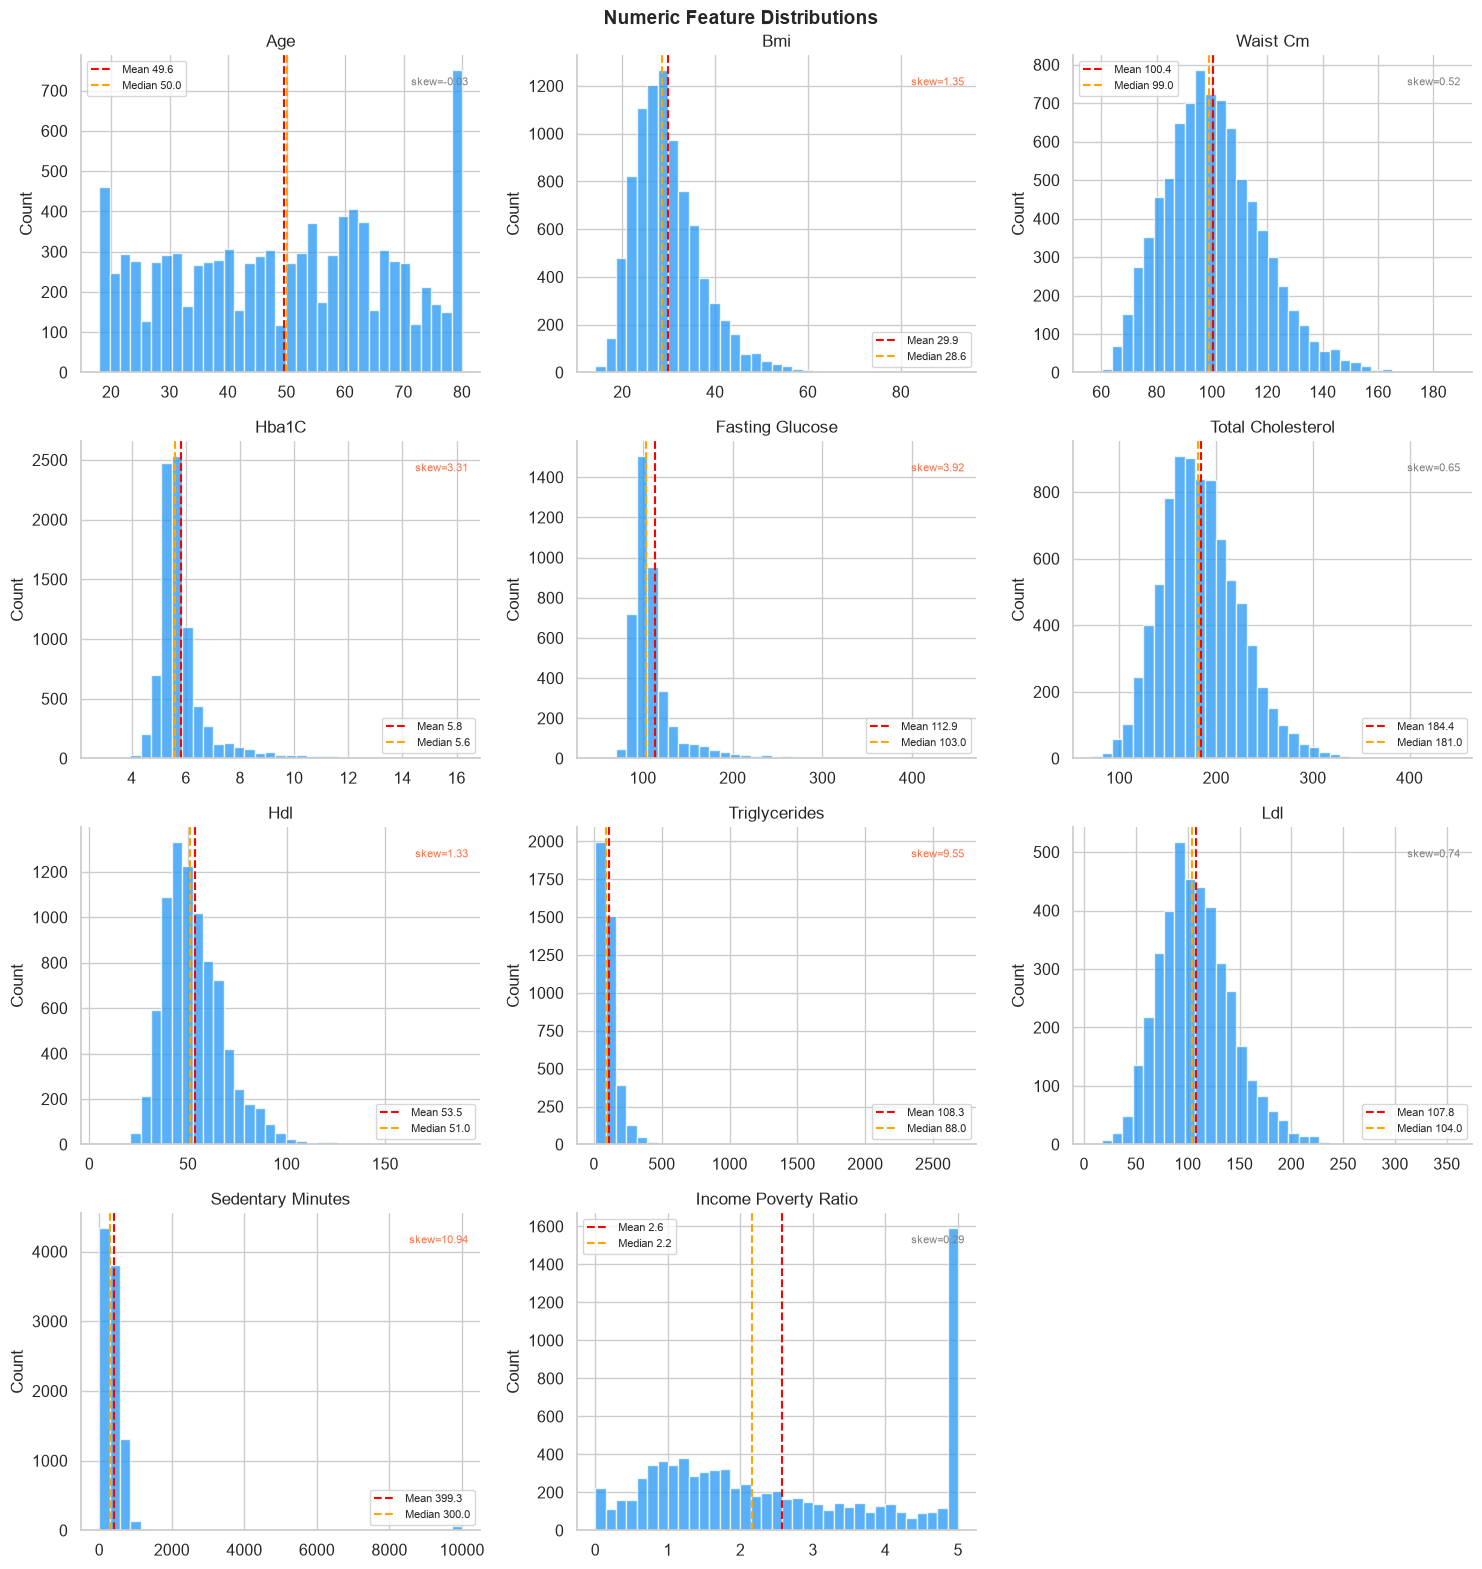

In [86]:
ncols = 3
nrows = -(-len(NUM_COLS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = np.array(axes).flatten()

for i, col in enumerate(NUM_COLS):
    data = df[col].dropna()
    axes[i].hist(data, bins=35, color=BLUE, alpha=0.75, edgecolor="white")
    axes[i].axvline(data.mean(),   color="red",    ls="--", lw=1.5,
                    label=f"Mean {data.mean():.1f}")
    axes[i].axvline(data.median(), color="orange", ls="--", lw=1.5,
                    label=f"Median {data.median():.1f}")
    axes[i].set_title(col.replace("_"," ").title())
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)

    skew = data.skew()
    axes[i].text(0.97, 0.93, f"skew={skew:.2f}",
                 transform=axes[i].transAxes, ha="right", va="top",
                 fontsize=8, color=ORANGE if abs(skew) > 1 else "gray")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.7 Categorical Feature Counts

How many adults fall into each category for non-numeric columns.


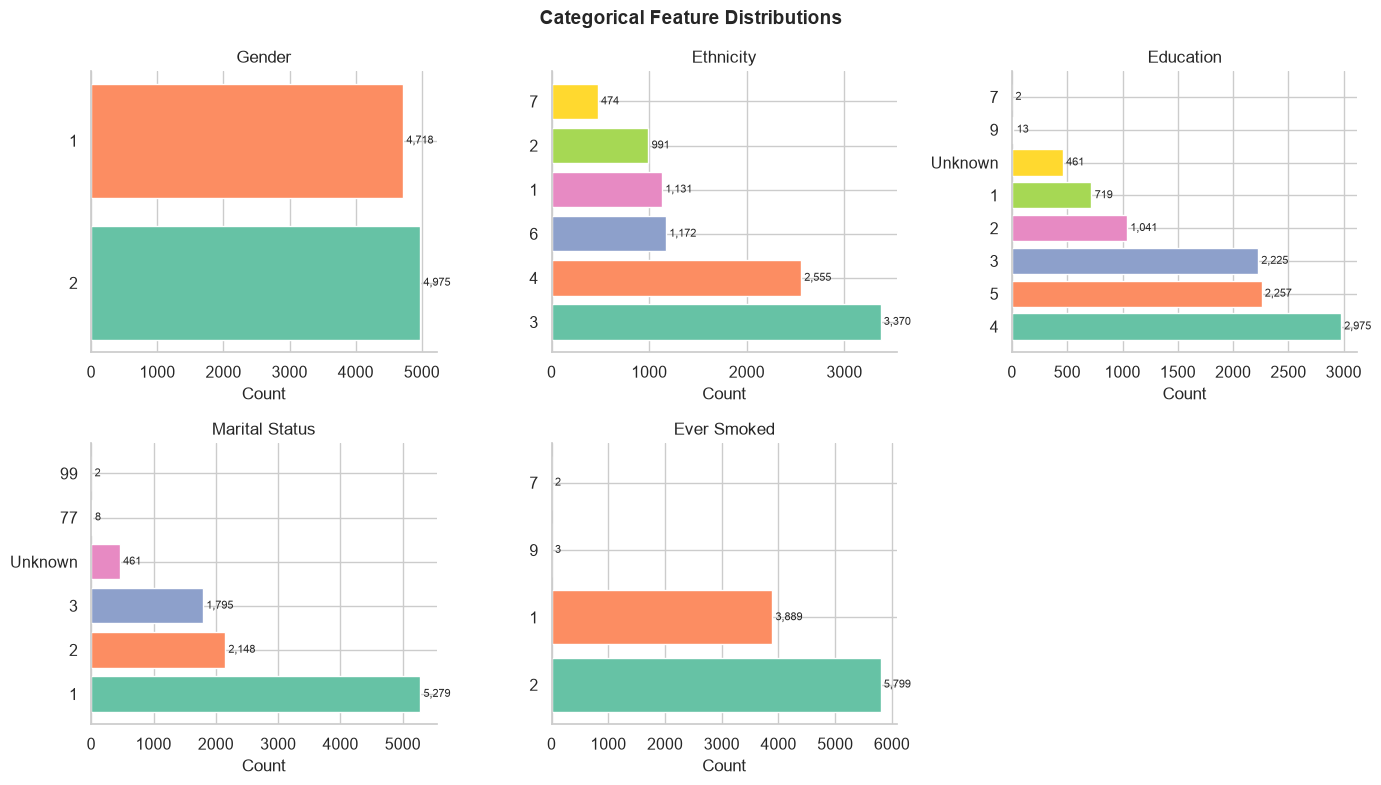

In [87]:
if CAT_COLS:
    ncols = min(3, len(CAT_COLS))
    nrows = -(-len(CAT_COLS) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(CAT_COLS):
        vc = df[col].value_counts(dropna=False)
        # Convert index safely to strings (handles NaN values)
        labels = [str(int(v)) if str(v) != "nan" else "Unknown" for v in vc.index]
        axes[i].barh(labels, vc.values,
                     color=sns.color_palette("Set2", len(vc)))
        axes[i].set_title(col.replace("_"," ").title())
        axes[i].set_xlabel("Count")
        for k, v in enumerate(vc.values):
            axes[i].text(v + vc.max()*0.01, k, f"{v:,}", va="center", fontsize=8)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

### 4.9 Correlation Between Features

This heatmap shows how strongly pairs of features are related.

- **Red (+1.0)** = when one goes up, the other goes up too
- **Blue (-1.0)** = when one goes up, the other goes down
- **White (0.0)** = no relationship

Values near 1 or -1 suggest the two features carry similar information.


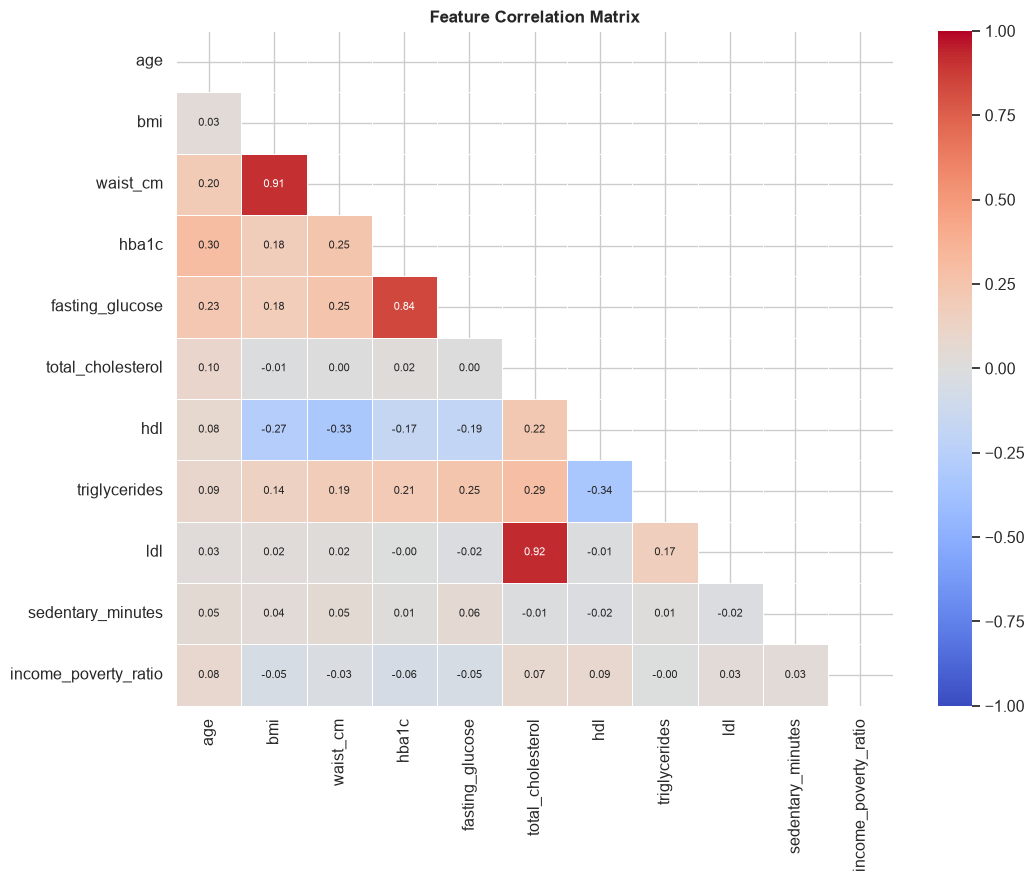

In [88]:
corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (it's a mirror)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.4, linecolor="white",
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

### 4.10 Multicollinearity Check (VIF)

**VIF** (Variance Inflation Factor) measures whether a feature is redundant
because it's highly correlated with other features.

| VIF | Meaning |
|-----|---------|
| 1 | No redundancy |
| 1–5 | Low — fine to keep |
| 5–10 | High — consider removing |
| > 10 | Very high — likely redundant |


In [89]:
vif_data = df[NUM_COLS].dropna()

vif_df = pd.DataFrame({
    "Feature": NUM_COLS,
    "VIF": [variance_inflation_factor(vif_data.values, i)
            for i in range(len(NUM_COLS))]
}).sort_values("VIF", ascending=False)

display(vif_df.style
    .background_gradient(cmap="Reds", subset=["VIF"])
    .format({"VIF": "{:.2f}"}))

,Feature,VIF
5,total_cholesterol,20849.23
8,ldl,15839.63
6,hdl,3089.30
7,triglycerides,1922.13
2,waist_cm,7.53
1,bmi,6.87
3,hba1c,3.76
4,fasting_glucose,3.68
0,age,1.37
10,income_poverty_ratio,1.03


### 4.11 Outliers

An outlier is a value that is very far from the typical range.
We use the **IQR method** to flag them:

```
Lower limit = Q1 - 1.5 × IQR
Upper limit = Q3 + 1.5 × IQR
```

> **Important:** In medical data, outliers often represent real extreme cases
> (e.g., very high blood sugar in an uncontrolled diabetic). We keep them — they carry useful signal.


In [90]:
rows = []
for col in NUM_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr     = q3 - q1
    n       = df[col].notna().sum()
    n_out   = ((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum()
    rows.append({"Feature": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                 "Outliers": n_out, "Outlier %": n_out/n*100})

out_df = pd.DataFrame(rows).sort_values("Outlier %", ascending=False)
display(out_df.style
    .background_gradient(cmap="Oranges", subset=["Outlier %"])
    .format({"Q1":"{:.1f}","Q3":"{:.1f}","IQR":"{:.1f}",
             "Outliers":"{:,}","Outlier %":"{:.1f}%"}))

,Feature,Q1,Q3,IQR,Outliers,Outlier %
4,fasting_glucose,95.0,114.0,19.0,420,10.1%
3,hba1c,5.3,6.0,0.7,731,8.6%
7,triglycerides,59.0,131.0,72.0,209,5.1%
1,bmi,24.7,33.6,8.9,280,3.2%
6,hdl,42.0,62.0,20.0,189,2.3%
9,sedentary_minutes,180.0,480.0,300.0,155,1.6%
8,ldl,83.0,129.0,46.0,57,1.4%
2,waist_cm,88.1,111.0,22.9,111,1.3%
5,total_cholesterol,155.0,210.0,55.0,104,1.3%
0,age,33.0,64.0,31.0,0,0.0%


### 4.12 Do Diseases Appear Together?

The **Phi coefficient** measures how often two diseases occur in the same patient.
- **0.0** = no relationship
- **1.0** = always appear together


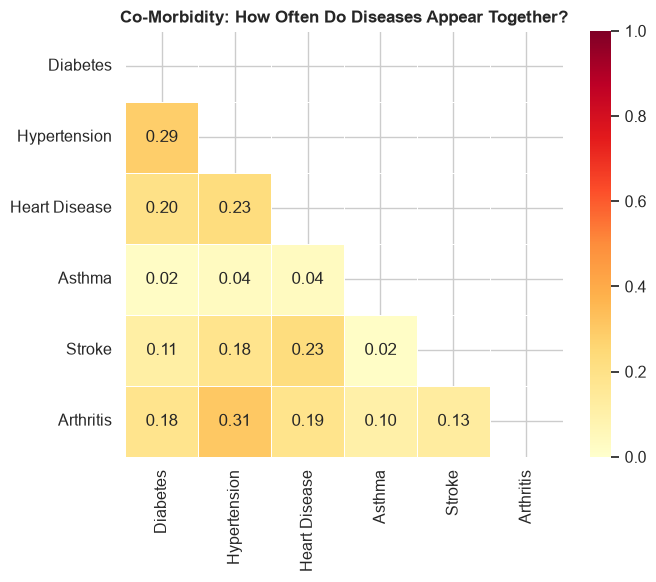

In [91]:
def phi(x, y):
    """Compute phi coefficient between two binary columns."""
    m = x.notna() & y.notna()
    a, b = x[m].astype(int), y[m].astype(int)
    n11 = ((a==1)&(b==1)).sum()
    n10 = ((a==1)&(b==0)).sum()
    n01 = ((a==0)&(b==1)).sum()
    n00 = ((a==0)&(b==0)).sum()
    d = np.sqrt((n11+n10)*(n01+n00)*(n11+n01)*(n10+n00))
    return (n11*n00 - n10*n01) / d if d else 0.0

labels = [DISEASE_NICE[t] for t in disease_targets]
mat    = np.array([[phi(df[t1], df[t2]) for t2 in disease_targets]
                   for t1 in disease_targets])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pd.DataFrame(mat, index=labels, columns=labels),
            mask=np.triu(np.ones_like(mat, dtype=bool)),
            annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Co-Morbidity: How Often Do Diseases Appear Together?",
             fontweight="bold")
plt.tight_layout()
plt.show()

### 4.13 EDA Summary

A quick printout of the most important findings.


In [92]:
print("=" * 55)
print("EDA KEY FINDINGS")
print("=" * 55)

# 1. Imbalance ratios
print("\n[1] Disease Imbalance (negative:positive ratio)")
for t in disease_targets:
    vc  = df[t].value_counts(dropna=True)
    neg, pos = vc.get(0, 0), vc.get(1, 0)
    ratio = neg/pos if pos else float("inf")
    flag  = "  <-- very imbalanced" if ratio > 5 else ""
    print(f"  {DISEASE_NICE[t]:<20}: {ratio:.1f}:1{flag}")

# 2. Strong correlations
corr = df[NUM_COLS].corr()
pairs = (corr.where(np.tril(np.ones_like(corr), k=-1).astype(bool))
             .stack().abs().sort_values(ascending=False))
print("\n[2] Strongest Feature Correlations (|r| > 0.4)")
for (c1, c2), v in pairs[pairs > 0.4].head(6).items():
    print(f"  {c1} <-> {c2}: r = {v:.2f}")

# 3. High missingness
miss = df.isnull().mean()
high = miss[miss > 0.3].sort_values(ascending=False)
print(f"\n[3] Columns with >30% missing: {len(high)}")
for col, pct in high.items():
    print(f"  {col:<28}: {pct:.0%}")

print("\n" + "=" * 55)
print("EDA done. Next: build the models.")

EDA KEY FINDINGS

[1] Disease Imbalance (negative:positive ratio)
  Diabetes            : 5.8:1  <-- very imbalanced
  Hypertension        : 1.7:1
  Heart Disease       : 11.7:1  <-- very imbalanced
  Asthma              : 5.3:1  <-- very imbalanced
  Stroke              : 17.9:1  <-- very imbalanced
  Arthritis           : 2.3:1

[2] Strongest Feature Correlations (|r| > 0.4)
  ldl <-> total_cholesterol: r = 0.92
  waist_cm <-> bmi: r = 0.91
  fasting_glucose <-> hba1c: r = 0.84

[3] Columns with >30% missing: 114
  RIDAGEMN                    : 100%
  BMIRECUM                    : 100%
  BMIHEAD                     : 100%
  BMXRECUM                    : 100%
  BMXHEAD                     : 100%
  SMD630                      : 100%
  SMQ621                      : 100%
  MCQ149                      : 100%
  RHD018                      : 100%
  MCQ151                      : 100%
  MCQ230D                     : 100%
  MCQ510B                     : 100%
  MCQ230C                     : 100

## 5. Train Disease Prediction Models

We train **one model per disease** using `HistGradientBoostingClassifier`.

**Why this algorithm?**
- Handles missing values automatically (no need to fill them in)
- Very fast and accurate
- Easy to control overfitting

**What is overfitting?**
> The model memorises the training data instead of learning general patterns.
> It scores high on training data but poorly on new patients.
> We measure this with: `Delta = Train AUC − Test AUC`
> - Delta < 0.08 → Good
> - Delta > 0.15 → Overfitting

**How we prevent it:**
Each disease gets its own settings — diseases that overfitted get stricter limits.


In [93]:
# Settings for each disease
# Diseases that overfit (Asthma, Stroke, Heart Disease, Arthritis) get
# stricter settings: shallower trees, more regularisation, early stopping
CONFIGS = {
    "target_diabetes":     dict(max_depth=5, min_samples_leaf=20, l2_regularization=1.0,
                                learning_rate=0.05, max_iter=150, early_stopping=False),
    "target_hypertension": dict(max_depth=5, min_samples_leaf=20, l2_regularization=1.0,
                                learning_rate=0.05, max_iter=150, early_stopping=False),
    "target_heart_disease":dict(max_depth=3, min_samples_leaf=40, l2_regularization=5.0,
                                learning_rate=0.03, max_iter=200, early_stopping=True,
                                validation_fraction=0.15, n_iter_no_change=15),
    "target_asthma":       dict(max_depth=2, min_samples_leaf=60, l2_regularization=10.0,
                                learning_rate=0.02, max_iter=300, early_stopping=True,
                                validation_fraction=0.20, n_iter_no_change=20),
    "target_stroke":       dict(max_depth=3, min_samples_leaf=50, l2_regularization=8.0,
                                learning_rate=0.02, max_iter=250, early_stopping=True,
                                validation_fraction=0.20, n_iter_no_change=20),
    "target_arthritis":    dict(max_depth=4, min_samples_leaf=30, l2_regularization=3.0,
                                learning_rate=0.04, max_iter=150, early_stopping=True,
                                validation_fraction=0.15, n_iter_no_change=15),
}

trained_models = {}
results        = []

for disease in disease_targets:
    name = disease.replace("target_","").replace("_"," ").upper()
    print(f"\nTraining: {name}")
    print("-" * 40)

    # Remove rows where this disease label is unknown
    data = df.dropna(subset=[disease]).copy()
    X    = data[selected_features]
    y    = data[disease].astype(int)

    # Split: 80% training, 20% testing (stratified = same ratio in both splits)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"  Patients: {len(y):,}  |  Disease rate: {y.mean():.1%}")

    # Train the model
    cfg   = CONFIGS.get(disease, CONFIGS["target_diabetes"])
    model = HistGradientBoostingClassifier(class_weight="balanced",
                                           random_state=42, **cfg)
    model.fit(X_train, y_train)
    trained_models[disease] = model

    # Evaluate
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_test)[:,1])
    delta     = train_auc - test_auc
    status    = "OK" if delta < 0.08 else "mild" if delta < 0.12 else "overfit"

    print(f"  Train AUC : {train_auc:.3f}")
    print(f"  Test  AUC : {test_auc:.3f}  (delta={delta:+.3f} -> {status})")

    results.append({
        "Disease":   disease.replace("target_","").replace("_"," ").title(),
        "Test AUC":  round(test_auc,  3),
        "Train AUC": round(train_auc, 3),
        "Delta":     round(delta,     3),
        "Status":    status,
    })

# Summary table
summary = pd.DataFrame(results)

def highlight(v):
    if v < 0.08: return "background-color: #c8e6c9"   # green = good
    if v < 0.12: return "background-color: #fff9c4"   # yellow = mild
    return "background-color: #ffcdd2"                 # red = overfit


Training: DIABETES
----------------------------------------
  Patients: 9,688  |  Disease rate: 14.7%
  Train AUC : 0.976
  Test  AUC : 0.934  (delta=+0.042 -> OK)

Training: HYPERTENSION
----------------------------------------
  Patients: 9,681  |  Disease rate: 37.0%
  Train AUC : 0.885
  Test  AUC : 0.811  (delta=+0.074 -> OK)

Training: HEART DISEASE
----------------------------------------
  Patients: 9,180  |  Disease rate: 7.9%
  Train AUC : 0.880
  Test  AUC : 0.810  (delta=+0.070 -> OK)

Training: ASTHMA
----------------------------------------
  Patients: 9,683  |  Disease rate: 15.9%
  Train AUC : 0.665
  Test  AUC : 0.607  (delta=+0.058 -> OK)

Training: STROKE
----------------------------------------
  Patients: 9,216  |  Disease rate: 5.3%
  Train AUC : 0.828
  Test  AUC : 0.784  (delta=+0.044 -> OK)

Training: ARTHRITIS
----------------------------------------
  Patients: 9,206  |  Disease rate: 30.5%
  Train AUC : 0.843
  Test  AUC : 0.782  (delta=+0.061 -> OK)


### 5.2 Model Evaluation

For each disease we produce three charts and a full metrics table:

| Chart | What it shows |
|-------|--------------|
| **ROC Curve** | Tradeoff between catching sick patients vs. false alarms at every threshold |
| **Precision-Recall Curve** | More useful than ROC when sick patients are rare |
| **Confusion Matrix** | Exact counts of correct and incorrect predictions |

**Metrics explained:**

| Metric | What it measures |
|--------|-----------------|
| **ROC-AUC** | Overall ranking — 0.5 = random, 1.0 = perfect |
| **PR-AUC** | Performance on the rare positive (sick) class |
| **Precision** | Of patients flagged AT RISK, how many are actually sick? |
| **Recall** | Of all sick patients, how many did we catch? |
| **F1** | Balance between Precision and Recall |



  Diabetes
  ROC-AUC : 0.934   |   PR-AUC : 0.767

              precision    recall  f1-score   support

    Negative       0.97      0.87      0.92      1653
    Positive       0.52      0.84      0.64       285

    accuracy                           0.86      1938
   macro avg       0.74      0.85      0.78      1938
weighted avg       0.90      0.86      0.87      1938



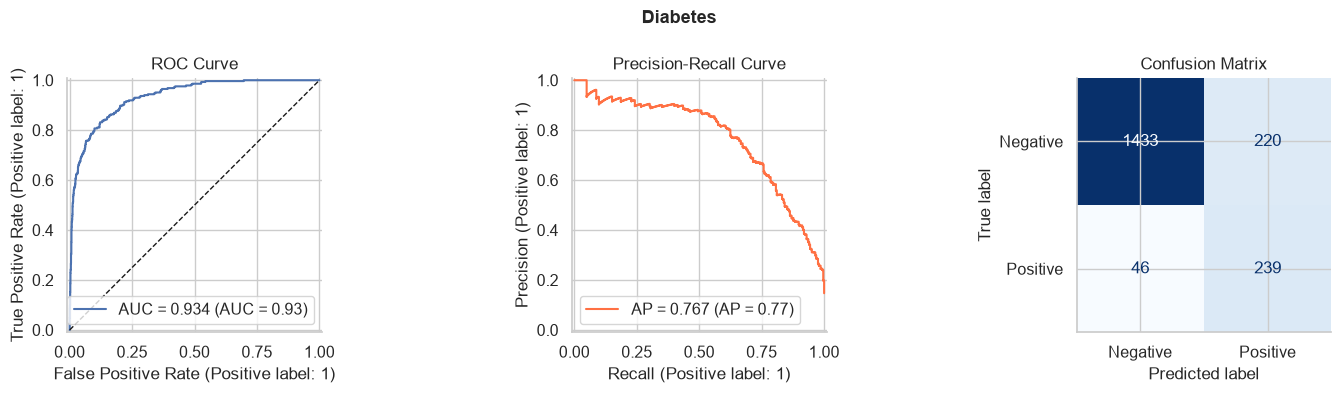


  Hypertension
  ROC-AUC : 0.811   |   PR-AUC : 0.708

              precision    recall  f1-score   support

    Negative       0.83      0.73      0.78      1221
    Positive       0.62      0.74      0.67       716

    accuracy                           0.73      1937
   macro avg       0.72      0.73      0.72      1937
weighted avg       0.75      0.73      0.74      1937



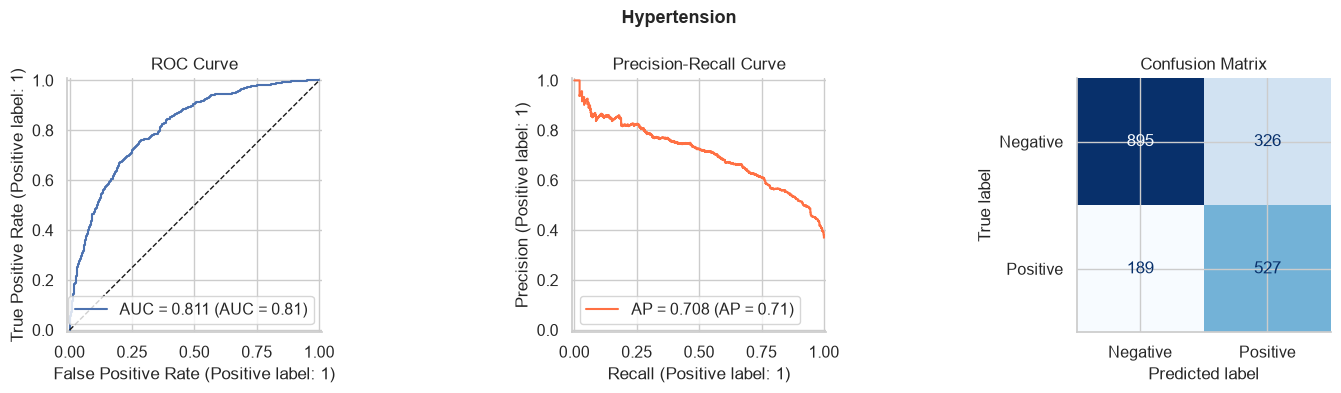


  Heart Disease
  ROC-AUC : 0.810   |   PR-AUC : 0.261

              precision    recall  f1-score   support

    Negative       0.97      0.73      0.83      1691
    Positive       0.19      0.74      0.30       145

    accuracy                           0.73      1836
   macro avg       0.58      0.73      0.57      1836
weighted avg       0.91      0.73      0.79      1836



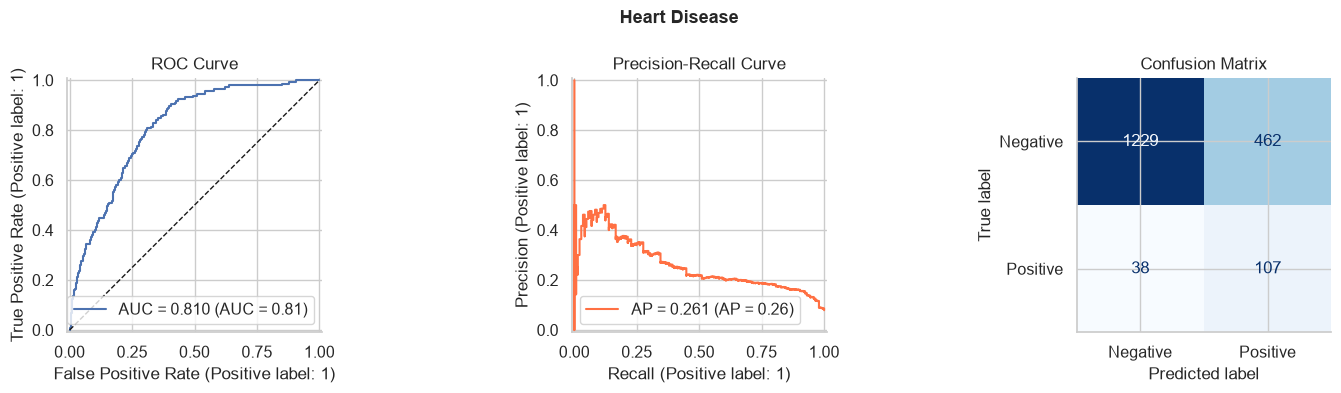


  Asthma
  ROC-AUC : 0.607   |   PR-AUC : 0.238

              precision    recall  f1-score   support

    Negative       0.88      0.67      0.76      1630
    Positive       0.22      0.51      0.31       307

    accuracy                           0.64      1937
   macro avg       0.55      0.59      0.53      1937
weighted avg       0.77      0.64      0.69      1937



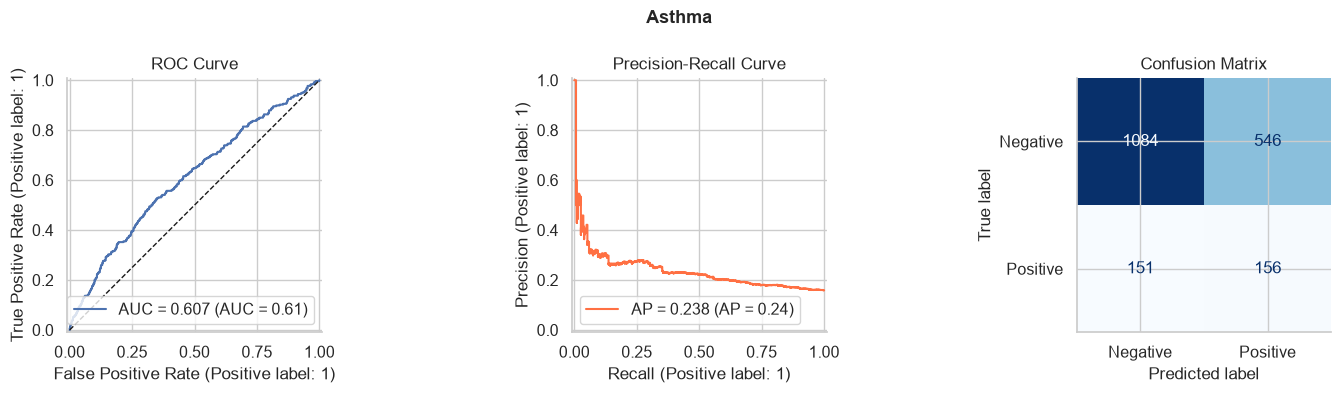


  Stroke
  ROC-AUC : 0.784   |   PR-AUC : 0.154

              precision    recall  f1-score   support

    Negative       0.98      0.66      0.79      1747
    Positive       0.11      0.75      0.19        97

    accuracy                           0.66      1844
   macro avg       0.54      0.71      0.49      1844
weighted avg       0.93      0.66      0.76      1844



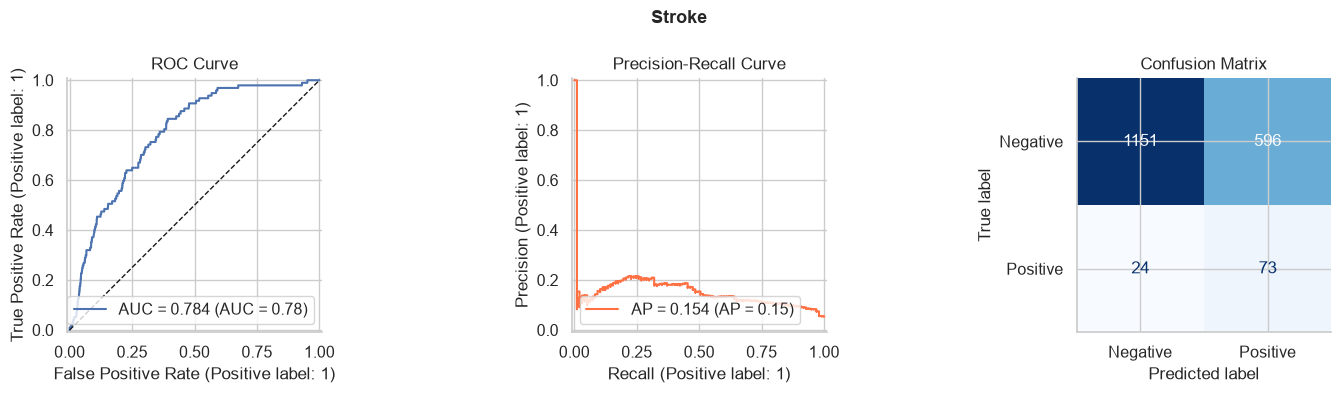


  Arthritis
  ROC-AUC : 0.782   |   PR-AUC : 0.575

              precision    recall  f1-score   support

    Negative       0.86      0.66      0.75      1279
    Positive       0.50      0.77      0.60       563

    accuracy                           0.69      1842
   macro avg       0.68      0.71      0.68      1842
weighted avg       0.75      0.69      0.70      1842



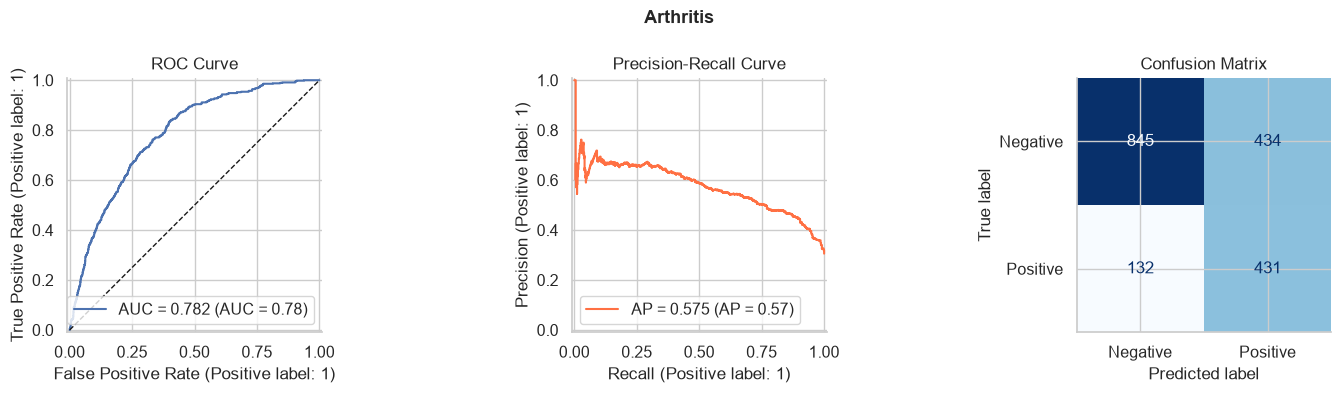

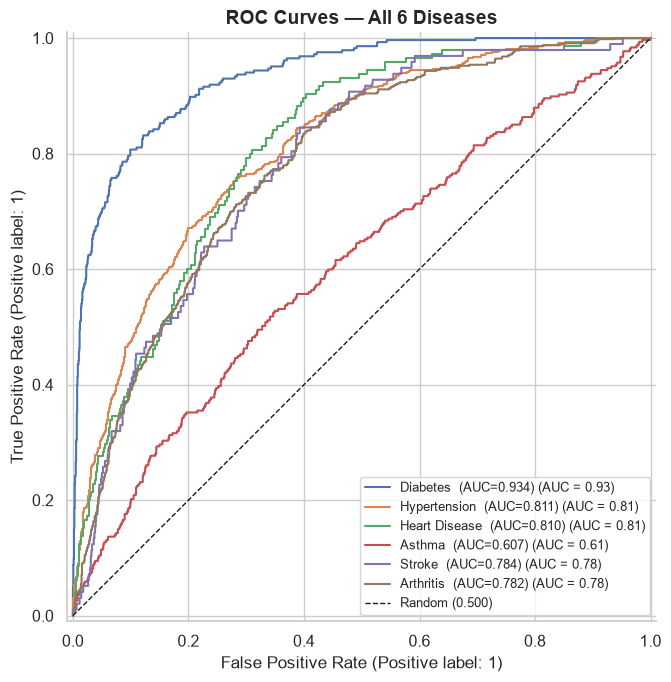


COMPLETE EVALUATION SUMMARY


,Disease,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Diabetes,0.934,0.767,0.521,0.839,0.642
1,Hypertension,0.811,0.708,0.618,0.736,0.672
2,Heart Disease,0.810,0.261,0.188,0.738,0.300
3,Asthma,0.607,0.238,0.222,0.508,0.309
4,Stroke,0.784,0.154,0.109,0.753,0.191
5,Arthritis,0.782,0.575,0.498,0.766,0.604


In [96]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
)

BLUE   = "#2196F3"
ORANGE = "#FF7043"

# ── Per-disease: ROC, PR curve, Confusion Matrix ──────────────────────────────
for disease in disease_targets:
    name  = disease.replace("target_","").replace("_"," ").title()
    data  = df.dropna(subset=[disease]).copy()
    X_    = data[selected_features]
    y_    = data[disease].astype(int)
    _, X_test, _, y_test = train_test_split(
        X_, y_, test_size=0.2, random_state=42, stratify=y_)
    model  = trained_models[disease]
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_prob)
    pr  = average_precision_score(y_test, y_prob)

    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(f"  ROC-AUC : {roc:.3f}   |   PR-AUC : {pr:.3f}")
    print()
    print(classification_report(y_test, y_pred,
                                target_names=["Negative", "Positive"]))

    # Three plots in one row
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(name, fontsize=13, fontweight="bold")

    # ROC curve
    RocCurveDisplay.from_predictions(
        y_test, y_prob, ax=axes[0], name=f"AUC = {roc:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", lw=1)
    axes[0].set_title("ROC Curve")

    # Precision-Recall curve
    PrecisionRecallDisplay.from_predictions(
        y_test, y_prob, ax=axes[1], color=ORANGE, name=f"AP = {pr:.3f}")
    axes[1].set_title("Precision-Recall Curve")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(
        ax=axes[2], colorbar=False, cmap="Blues")
    axes[2].set_title("Confusion Matrix")

    plt.tight_layout()
    plt.show()

# ── All ROC curves on one chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.Set2(np.linspace(0, 1, len(disease_targets)))

for (disease, model), color in zip(trained_models.items(), colors):
    name  = disease.replace("target_","").replace("_"," ").title()
    data  = df.dropna(subset=[disease]).copy()
    X_    = data[selected_features]
    y_    = data[disease].astype(int)
    _, X_test, _, y_test = train_test_split(
        X_, y_, test_size=0.2, random_state=42, stratify=y_)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc    = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(
        y_test, y_prob, ax=ax,
        name=f"{name}  (AUC={roc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (0.500)")
ax.set_title("ROC Curves — All 6 Diseases", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# ── Final summary table ───────────────────────────────────────────────────────
eval_rows = []
for disease in disease_targets:
    name  = disease.replace("target_","").replace("_"," ").title()
    data  = df.dropna(subset=[disease]).copy()
    X_    = data[selected_features]
    y_    = data[disease].astype(int)
    _, X_test, _, y_test = train_test_split(
        X_, y_, test_size=0.2, random_state=42, stratify=y_)
    model  = trained_models[disease]
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    eval_rows.append({
        "Disease":   name,
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 3),
        "PR-AUC":    round(average_precision_score(y_test, y_prob), 3),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 3),
        "Recall":    round(recall_score(y_test, y_pred, zero_division=0), 3),
        "F1":        round(f1_score(y_test, y_pred, zero_division=0), 3),
    })

eval_df = pd.DataFrame(eval_rows)
print("\nCOMPLETE EVALUATION SUMMARY")
display(eval_df.style
    .background_gradient(cmap="Greens",
                         subset=["ROC-AUC", "PR-AUC", "F1"])
    .format({c: "{:.3f}" for c in
             ["ROC-AUC","PR-AUC","Precision","Recall","F1"]}))

## 6. Patient Risk Report

Given a patient's measurements, all 6 models run at once and produce a unified risk profile.

**Risk score** = probability (0–100%) that the patient has each disease.
- Score > 50% → flagged as **AT RISK**
- Score ≤ 50% → **Low Risk**


In [ ]:
def patient_report(patient_row, models):
    """Print a risk report for one patient."""
    age = patient_row["age"].values[0]
    bmi = patient_row["bmi"].values[0]
    print(f"\nPatient: Age {age:.0f}, BMI {bmi:.1f}")
    print("-" * 45)
    for disease, model in models.items():
        name  = disease.replace("target_","").replace("_"," ").title()
        prob  = model.predict_proba(patient_row)[0][1]
        label = "AT RISK" if prob > 0.5 else "Low Risk"
        bar   = "#" * int(prob * 20)   # simple progress bar
        print(f"  {name:<15} {label:<10}  {prob*100:5.1f}%  [{bar:<20}]")
    print("-" * 45)


# Test on 3 random patients who have all features available
complete_cases = df.dropna(subset=selected_features + disease_targets)
sample = complete_cases.sample(3, random_state=42)

for i, (_, row) in enumerate(sample.iterrows()):
    print(f"\n[ PATIENT {i+1} ]")
    patient_report(row[selected_features].to_frame().T, trained_models)


[ PATIENT 1 ]

Patient: Age 40, BMI 38.8
---------------------------------------------
  Diabetes        Low Risk      3.2%  [                    ]
  Hypertension    Low Risk     35.3%  [#######             ]
  Heart Disease   Low Risk      6.6%  [#                   ]
  Asthma          AT RISK      55.9%  [###########         ]
  Stroke          Low Risk     24.0%  [####                ]
  Arthritis       AT RISK      57.6%  [###########         ]
---------------------------------------------

[ PATIENT 2 ]

Patient: Age 80, BMI 29.4
---------------------------------------------
  Diabetes        Low Risk     40.6%  [########            ]
  Hypertension    AT RISK      76.9%  [###############     ]
  Heart Disease   AT RISK      62.7%  [############        ]
  Asthma          Low Risk     39.3%  [#######             ]
  Stroke          AT RISK      59.8%  [###########         ]
  Arthritis       AT RISK      84.0%  [################    ]
---------------------------------------------


## 7. Save Models for Backend API

Saves the trained models and the feature list so they can be loaded by the FastAPI backend.

In [ ]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(trained_models, MODEL_DIR / "trained_models.joblib")
joblib.dump(selected_features, MODEL_DIR / "selected_features.joblib")
print(f"Models and feature list successfully saved to {MODEL_DIR.resolve()}")